In [220]:
import pandas as pd
import os

## 1. Load data

In [221]:
batch_path = os.getcwd()
path = os.path.join(batch_path, '..', 'Data', 'Housing.csv')
df = pd.read_csv(path)

In [222]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## 2. convert the x = data, y = label

In [224]:
X = df.drop(columns=['price', 'furnishingstatus'])
y = (df['price'] / 1000).astype(float)
 



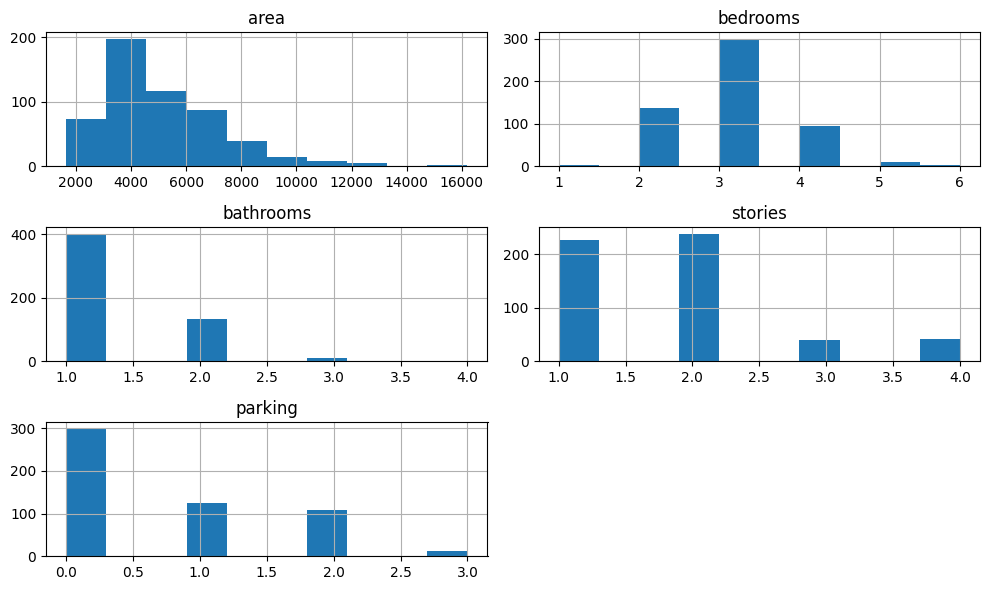

In [225]:
import matplotlib.pyplot as plt
X.hist(figsize=(10, 6))
plt.tight_layout()


In [226]:
cat_col = X.select_dtypes(include=('object')).columns
num_col = X.select_dtypes(include=(['int64', 'float64'])).columns

len(X.columns) == len(cat_col)+len(num_col)

True

In [227]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. label encoder

In [228]:
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, RobustScaler
encoder = LabelEncoder()
for label in cat_col:
    X[label] = encoder.fit_transform(X[label])

X['parking'].value_counts()
                   

parking
0    299
1    126
2    108
3     12
Name: count, dtype: int64

In [229]:
X.value_counts()

area   bedrooms  bathrooms  stories  mainroad  guestroom  basement  hotwaterheating  airconditioning  parking  prefarea
3640   2         1          1        1         0          0         0                0                0        0           3
3600   2         1          1        1         0          0         0                0                0        0           3
4040   2         1          1        1         0          0         0                0                0        0           3
2145   3         1          3        1         0          0         0                0                0        1           2
4000   3         1          2        1         0          0         0                0                1        0           2
                                                                                                                          ..
12944  3         1          1        1         0          0         0                0                0        0           1
13200

In [230]:
X = X.astype(float)
y = y.astype(float)
 

## 4. trainin data spliting

In [231]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# covert the data in scaled from
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)


In [232]:
import joblib as jb
path_scale = os.getcwd()
path_scaled = os.path.join(path_scale, '..', 'scaled.pkl')
jb.dump(scale,path_scaled)

['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\-House-Price-Prediction-using-Machine-Learning\\notebook\\..\\scaled.pkl']

In [233]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


## 5. model

In [234]:
from sklearn.ensemble import GradientBoostingRegressor
model_0 = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.85,
    max_features="sqrt",
    random_state=42
)
model_0.fit(X_train, y_train_log)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.85
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [235]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

def predict_function(model, data, ans_log):
    # Convert predictions back to original scale (no int casting)
    y_pred = np.expm1(model.predict(data))
    
    # Convert true values back to original scale
    y_true = np.expm1(ans_log)
    
    # Model score (R^2) on log-transformed data
    score = model.score(data, ans_log)
    
    print('Model Score:', score)
    print('MAPE (%):', mean_absolute_percentage_error(y_true, y_pred) * 100)

    return y_pred




In [236]:
m = predict_function(model_0, X_test, y_test_log)

Model Score: 0.648802123920512
MAPE (%): 20.85713759673634


In [237]:
pd.DataFrame({
    "true": y_test,
    "pred": m.astype(int)
}).sort_values("true").head(10)


,true,pred
543,1750.0,2711
540,1820.0,3471
538,1890.0,3067
537,1890.0,2798
533,2100.0,2864
531,2233.0,4083
529,2275.0,3991
523,2380.0,4122
516,2450.0,2984
517,2450.0,2958


In [238]:
df['area'].max(), df['area'].min()

(np.int64(16200), np.int64(1650))

## save model

In [239]:
import joblib as jb

batch_path_model = os.getcwd()

path = os.path.join(batch_path_model, '..', 'model.pkl')

jb.dump(model_0, path)

['c:\\Users\\sumit\\OneDrive\\Desktop\\project work\\-House-Price-Prediction-using-Machine-Learning\\notebook\\..\\model.pkl']

In [240]:
model = jb.load(path)

In [241]:
k = predict_function(model, X_test, y_test_log)

Model Score: 0.648802123920512
MAPE (%): 20.85713759673634


In [242]:
pd.DataFrame({
    "true": y_test,
    "pred": k.astype(int)
}).sort_values("true").head(10)


,true,pred
543,1750.0,2711
540,1820.0,3471
538,1890.0,3067
537,1890.0,2798
533,2100.0,2864
531,2233.0,4083
529,2275.0,3991
523,2380.0,4122
516,2450.0,2984
517,2450.0,2958


* correct model save

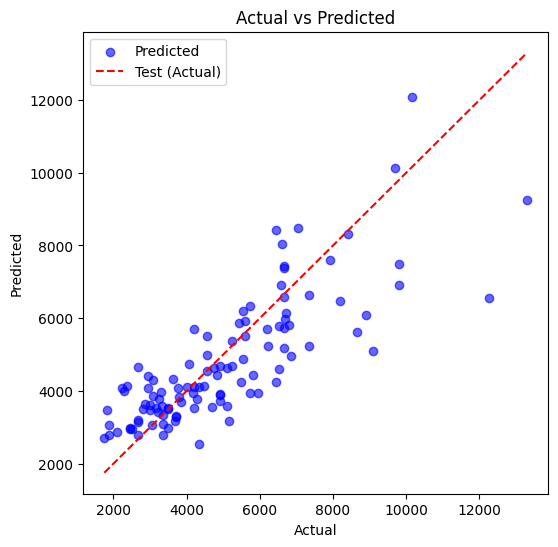

In [243]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Scatter plot: Actual vs Predicted
plt.scatter(y_test, k, color="blue", alpha=0.6, label="Predicted")

# Perfect prediction line (Actual = Predicted)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Test (Actual)"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()


## evalution for the model

In [244]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, k))
print("RMSE:", mean_squared_error(y_test, k))
print("R2:", r2_score(y_test, k))


MAE: 979.1577125033331
RMSE: 1822945.4991859687
R2: 0.6393470838596336


In [245]:
df['area'].max(), df['area'].min()

(np.int64(16200), np.int64(1650))